<class 'pandas.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pixel_0_0  1797 non-null   float64
 1   pixel_0_1  1797 non-null   float64
 2   pixel_0_2  1797 non-null   float64
 3   pixel_0_3  1797 non-null   float64
 4   pixel_0_4  1797 non-null   float64
 5   pixel_0_5  1797 non-null   float64
 6   pixel_0_6  1797 non-null   float64
 7   pixel_0_7  1797 non-null   float64
 8   pixel_1_0  1797 non-null   float64
 9   pixel_1_1  1797 non-null   float64
 10  pixel_1_2  1797 non-null   float64
 11  pixel_1_3  1797 non-null   float64
 12  pixel_1_4  1797 non-null   float64
 13  pixel_1_5  1797 non-null   float64
 14  pixel_1_6  1797 non-null   float64
 15  pixel_1_7  1797 non-null   float64
 16  pixel_2_0  1797 non-null   float64
 17  pixel_2_1  1797 non-null   float64
 18  pixel_2_2  1797 non-null   float64
 19  pixel_2_3  1797 non-null   float64
 20  pixel_2_4  1797 non

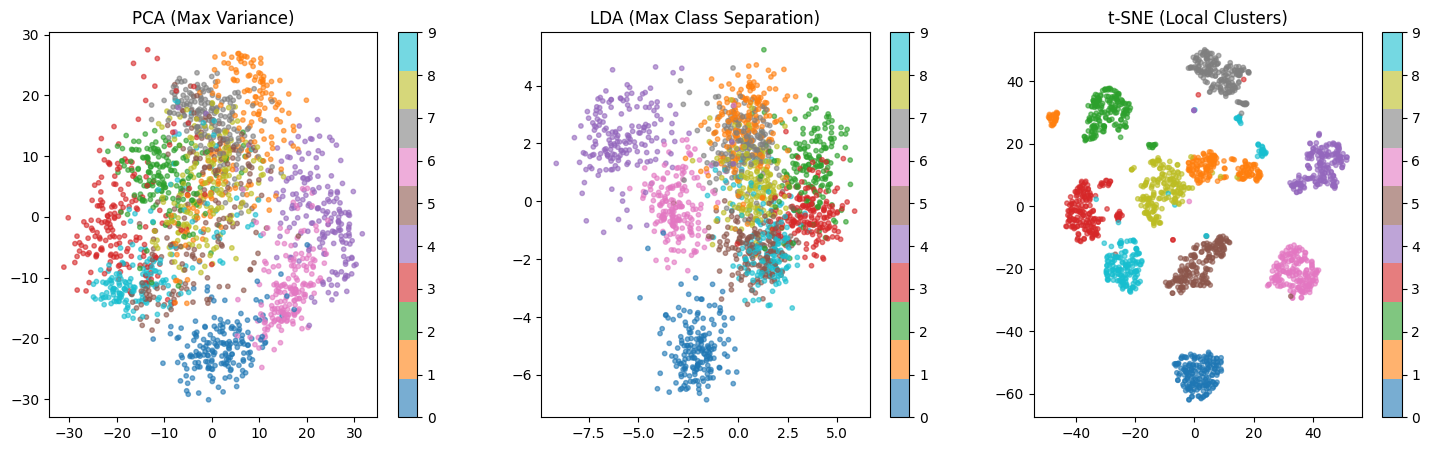

In [1]:
# we will see on available data on sklearn lib
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE

# Load Data (8x8 images of digits 0-9)
digits = datasets.load_digits(as_frame = True)

# for display purpose
digits_df = digits.frame
digits_df.describe()
digits_df.info()
#digits_df.head(5)

X, y = digits.data, digits.target

# Apply Dimensionality Reduction
pca_res = PCA(n_components=2).fit_transform(X)
lda_res = LDA(n_components=2).fit_transform(X, y) # Requires 'y' labels
tsne_res = TSNE(n_components=2, random_state=42).fit_transform(X)

# Visualize Results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['PCA (Max Variance)', 'LDA (Max Class Separation)', 't-SNE (Local Clusters)']
data_list = [pca_res, lda_res, tsne_res]

for ax, data, title in zip(axes, data_list, titles):
    scatter = ax.scatter(data[:, 0], data[:, 1], c=y, cmap='tab10', alpha=0.6, s=10)
    ax.set_title(title)
    fig.colorbar(scatter, ax=ax)

plt.show()


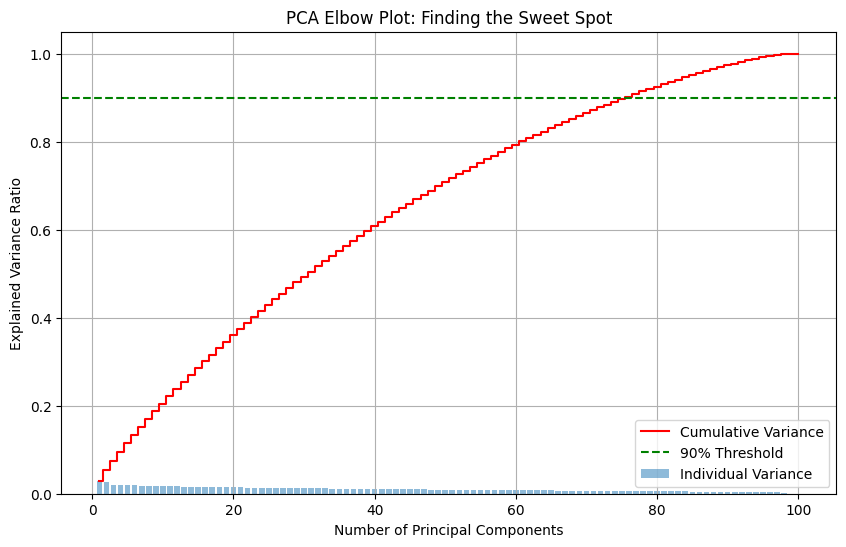

To keep 90% of the variance, you need 76 components.


In [2]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler

# Create a dummy dataset with 100 features
X, y = make_classification(n_samples=500, n_features=100, n_informative=15, random_state=42)

# Standardize the data (Vital for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA to all components to see the full "spectrum"
pca = PCA()
pca.fit(X_scaled)

# Calculate Individual and Cumulative Variance
exp_var_ratio = pca.explained_variance_ratio_
cum_var_ratio = np.cumsum(exp_var_ratio)

# Create the Elbow / Scree Plot
plt.figure(figsize=(10, 6))
plt.bar(range(1, 101), exp_var_ratio, alpha=0.5, label='Individual Variance')
plt.step(range(1, 101), cum_var_ratio, where='mid', label='Cumulative Variance', color='red')

# Add a 90% threshold line
plt.axhline(y=0.90, color='green', linestyle='--', label='90% Threshold')

plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Elbow Plot: Finding the Sweet Spot')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# Programmatically find the "Sweet Spot" for 90% variance
n_components_90 = np.argmax(cum_var_ratio >= 0.90) + 1
print(f"To keep 90% of the variance, you need {n_components_90} components.")

In [5]:
# we will now see how PCA affects performance

import pandas as pd
heart_disease_df = pd.read_csv('../data/CVD_cleaned.csv')

heart_disease_df.describe()
heart_disease_df.info()
heart_disease_df.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 308854 entries, 0 to 308853
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   General_Health                308854 non-null  str    
 1   Checkup                       308854 non-null  str    
 2   Exercise                      308854 non-null  str    
 3   Heart_Disease                 308854 non-null  str    
 4   Skin_Cancer                   308854 non-null  str    
 5   Other_Cancer                  308854 non-null  str    
 6   Depression                    308854 non-null  str    
 7   Diabetes                      308854 non-null  str    
 8   Arthritis                     308854 non-null  str    
 9   Sex                           308854 non-null  str    
 10  Age_Category                  308854 non-null  str    
 11  Height_(cm)                   308854 non-null  float64
 12  Weight_(kg)                   308854 non-null  float64


,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150.0,32.66,14.54,Yes,0.0,30.0,16.0,12.0
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165.0,77.11,28.29,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163.0,88.45,33.47,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180.0,93.44,28.73,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191.0,88.45,24.37,Yes,0.0,8.0,4.0,0.0


In [7]:
# check how many category variables are there
for col in heart_disease_df.columns:
    if heart_disease_df[col].dtype == 'str':
        print(f"============{col}============")
        print(heart_disease_df[col].value_counts())

============General_Health============
General_Health
Very Good    110395
Good          95364
Excellent     55954
Fair          35810
Poor          11331
Name: count, dtype: int64
============Checkup============
Checkup
Within the past year       239371
Within the past 2 years     37213
Within the past 5 years     17442
5 or more years ago         13421
Never                        1407
Name: count, dtype: int64
============Exercise============
Exercise
Yes    239381
No      69473
Name: count, dtype: int64
============Heart_Disease============
Heart_Disease
No     283883
Yes     24971
Name: count, dtype: int64
============Skin_Cancer============
Skin_Cancer
No     278860
Yes     29994
Name: count, dtype: int64
============Other_Cancer============
Other_Cancer
No     278976
Yes     29878
Name: count, dtype: int64
============Depression============
Depression
No     246953
Yes     61901
Name: count, dtype: int64
============Diabetes============
Diabetes
No                                

In [8]:
# Returns a count of every data type in your DataFrame
print(heart_disease_df.dtypes.value_counts())

str        12
float64     7
Name: count, dtype: int64


In [9]:
cat_cols = []
for col in heart_disease_df.columns:
    if heart_disease_df[col].dtype == 'str':
        cat_cols.append(col)
print(cat_cols)

['General_Health', 'Checkup', 'Exercise', 'Heart_Disease', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex', 'Age_Category', 'Smoking_History']


In [13]:
# BLIND LOGISTIC REGRESSION
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X = heart_disease_df.drop('Heart_Disease', axis=1)
y = heart_disease_df['Heart_Disease']

te_cols = ['General_Health', 'Checkup', 'Age_Category']
ohe_cols = [col for col in cat_cols if col not in te_cols and col != 'Heart_Disease']
#print(te_cols, ohe_cols)

# Define the Preprocessing (Encoding Only)
# We don't scale here yet because OHE/Target outputs aren't created until this runs.
preprocessor = ColumnTransformer(
    transformers=[
        #('num', 'passthrough', ['income', 'age']), # Keep numbers as-is for now
        ('ohe', OneHotEncoder(handle_unknown='ignore'), ohe_cols),
        ('te', TargetEncoder(target_type='binary'), te_cols)
    ])

# Create the Master Pipeline
# The Order: Encode -> Scale EVERY column -> Logistic Regression
full_pipeline = Pipeline(steps=[
    ('encoding', preprocessor),
    ('scaling', StandardScaler()), # This scales the outputs of all encoders + numeric columns
    ('classifier', LogisticRegression())
])

# Split and Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

full_pipeline.fit(X_train, y_train)

# Evaluate
y_pred = full_pipeline.predict(X_test)
print("--- Classification Report (Scaled Everything) ---")
print(classification_report(y_test, y_pred))


--- Classification Report (Scaled Everything) ---
              precision    recall  f1-score   support

          No       0.92      0.99      0.96     70930
         Yes       0.50      0.08      0.14      6284

    accuracy                           0.92     77214
   macro avg       0.71      0.54      0.55     77214
weighted avg       0.89      0.92      0.89     77214



In [14]:
# NOW we will apply PCA and see how it affects

# Build the Master Pipeline with PCA
# Order: Encode -> Scale -> PCA -> Logistic Regression
pca_pipeline = Pipeline(steps=[
    ('encoding', preprocessor),
    ('scaling', StandardScaler()), 
    ('pca', PCA(n_components=0.95)), # Keep components explaining 95% of variance
    ('classifier', LogisticRegression())
])

# Split and Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# The pipeline handles everything: 
pca_pipeline.fit(X_train, y_train)

# Evaluate
y_pred = pca_pipeline.predict(X_test)

print("--- PCA Pipeline Classification Report ---")
print(classification_report(y_test, y_pred))

# Deep Dive into PCA results
n_components = pca_pipeline.named_steps['pca'].n_components_
total_variance = np.sum(pca_pipeline.named_steps['pca'].explained_variance_ratio_)

print(f"Original feature count after encoding: ~6-8 (depending on unique cities)")
print(f"PCA reduced this to: {n_components} components")
print(f"Total variance captured by PCA: {total_variance:.2%}")

--- PCA Pipeline Classification Report ---
              precision    recall  f1-score   support

          No       0.92      0.99      0.96     85101
         Yes       0.51      0.06      0.11      7556

    accuracy                           0.92     92657
   macro avg       0.72      0.53      0.53     92657
weighted avg       0.89      0.92      0.89     92657

Original feature count after encoding: ~6-8 (depending on unique cities)
PCA reduced this to: 12 components
Total variance captured by PCA: 97.11%


In [15]:
# NOW we will apply logic to handle imbalanced data
# Build the Master Pipeline with PCA
# Order: Encode -> Scale -> PCA -> Logistic Regression
pca_pipeline = Pipeline(steps=[
    ('encoding', preprocessor),
    ('scaling', StandardScaler()), 
    ('pca', PCA(n_components=0.95)), # Keep components explaining 95% of variance
    ('classifier', LogisticRegression(class_weight='balanced')) # TWEAK
])

# Split and Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# The pipeline handles everything: 
pca_pipeline.fit(X_train, y_train)

# Evaluate
y_pred = pca_pipeline.predict(X_test)

print("--- PCA Pipeline Classification Report ---")
print(classification_report(y_test, y_pred))

# Deep Dive into PCA results
n_components = pca_pipeline.named_steps['pca'].n_components_
total_variance = np.sum(pca_pipeline.named_steps['pca'].explained_variance_ratio_)

print(f"Original feature count after encoding: ~6-8 (depending on unique cities)")
print(f"PCA reduced this to: {n_components} components")
print(f"Total variance captured by PCA: {total_variance:.2%}")

--- PCA Pipeline Classification Report ---
              precision    recall  f1-score   support

          No       0.97      0.74      0.84     85101
         Yes       0.20      0.73      0.32      7556

    accuracy                           0.74     92657
   macro avg       0.58      0.74      0.58     92657
weighted avg       0.91      0.74      0.80     92657

Original feature count after encoding: ~6-8 (depending on unique cities)
PCA reduced this to: 12 components
Total variance captured by PCA: 97.11%


In [23]:
# FIRST we will remove data 75% having target class same proportion as original data size as SVM is quite slow for huge data

print("Original Proportions:")
print(heart_disease_df['Heart_Disease'].value_counts(normalize=True))

# Remove 75% of the data proportionally
# test_size=0.5 means we "discard" 50% and "keep" 50%
# stratify=df['target'] ensures the 80/20 split remains the same
heart_disease_kept_df, heart_disease_discarded_df = train_test_split(
    heart_disease_df, 
    test_size=0.75, 
    random_state=42, 
    stratify=heart_disease_df['Heart_Disease']
)

print("\nNew Proportions (after removing 50%):")
print(heart_disease_kept_df['Heart_Disease'].value_counts(normalize=True))
print(f"\nTotal rows remaining: {len(heart_disease_kept_df)}")

heart_disease_kept_df.describe()
heart_disease_kept_df.info()
heart_disease_kept_df.head(5)

Original Proportions:
Heart_Disease
No     0.91915
Yes    0.08085
Name: proportion, dtype: float64

New Proportions (after removing 50%):
Heart_Disease
No     0.919146
Yes    0.080854
Name: proportion, dtype: float64

Total rows remaining: 77213
<class 'pandas.DataFrame'>
Index: 77213 entries, 67834 to 59471
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   General_Health                77213 non-null  str    
 1   Checkup                       77213 non-null  str    
 2   Exercise                      77213 non-null  str    
 3   Heart_Disease                 77213 non-null  str    
 4   Skin_Cancer                   77213 non-null  str    
 5   Other_Cancer                  77213 non-null  str    
 6   Depression                    77213 non-null  str    
 7   Diabetes                      77213 non-null  str    
 8   Arthritis                     77213 non-null  str    
 9   Sex

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
67834,Good,Within the past year,No,No,No,Yes,Yes,Yes,No,Female,45-49,168.0,104.33,37.12,No,0.0,0.0,4.0,2.0
255558,Very Good,Within the past year,Yes,No,No,No,Yes,"Yes, but female told only during pregnancy",Yes,Female,70-74,165.0,74.39,27.29,No,0.0,30.0,4.0,4.0
169638,Good,Within the past year,Yes,No,No,No,Yes,No,No,Female,25-29,165.0,81.65,29.95,Yes,0.0,16.0,8.0,4.0
77,Good,Within the past year,No,No,No,Yes,No,No,Yes,Female,65-69,173.0,79.83,26.76,No,0.0,0.0,4.0,0.0
44731,Fair,Within the past year,Yes,No,Yes,Yes,No,No,Yes,Male,65-69,180.0,99.79,30.68,Yes,1.0,8.0,0.0,4.0


In [24]:
# NOW we will work on LDA + SVM
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import SVC

# runs on modified dataset
X = heart_disease_kept_df.drop('Heart_Disease', axis=1)
y = heart_disease_kept_df['Heart_Disease']

# Preprocessing (Encode Categories)
# WE will borrow from previous one

# Master Pipeline: Encode -> Scale -> LDA -> SVM
# Note: LDA is supervised, so it needs 'y' during the fit process
lda_svm_pipeline = Pipeline(steps=[
    ('prep', preprocessor),
    ('scale', StandardScaler()),
    ('lda', LDA(n_components=1)), # Binary class = max 1 component
    ('svm', SVC(kernel='linear', class_weight='balanced'))
])

# Split and Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# LDA will use y_train to find the best separation axis
lda_svm_pipeline.fit(X_train, y_train)

# Interpret LDA before looking at SVM
lda_step = lda_svm_pipeline.named_steps['lda']
print(f"Variance explained by LDA component: {lda_step.explained_variance_ratio_[0]:.2%}")

# Evaluate Final Performance
y_pred = lda_svm_pipeline.predict(X_test)
print("\n--- SVM + LDA Classification Report ---")
print(classification_report(y_test, y_pred))

Variance explained by LDA component: 100.00%

--- SVM + LDA Classification Report ---
              precision    recall  f1-score   support

          No       0.97      0.74      0.84     21267
         Yes       0.21      0.76      0.32      1897

    accuracy                           0.74     23164
   macro avg       0.59      0.75      0.58     23164
weighted avg       0.91      0.74      0.80     23164

